# Phase 1 - Volume and portion training

This is the canonical training notebook for the project.

The app uses pretrained perception models for segmentation and food recognition. The part we train ourselves is the **quantity model**:

* with a side view: `area_cm2 + height_cm -> volume_ml -> grams`
* without a side view: class-specific `mass_per_cm2` priors are used as a labelled fallback

The reusable training code lives in `foodvol.training`; this notebook explains and visualises the workflow.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import pandas as pd

from foodvol import config, training
from foodvol.volume import VolumeEstimator

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
print(f"project root: {config.PROJECT_ROOT}")

project root: /Users/clemens/Developer/ml4b_foodrecognition


## 1. Load ECUSTFD volume features

ECUSTFD is the dataset that actually contains measured food **volume**. Each row is one weighed portion with a top image, a side image, coin-based metric scale, ground-truth volume and weight.

`artifacts/ecustfd_features_extended.csv` is the cached feature table extracted from those images. Rebuilding it requires the downloaded ECUSTFD images and FastSAM; training from the cache is fast.

In [2]:
df = training.load_ecustfd_features()
print(f"{len(df)} portions, {df.food_type.nunique()} food classes")
display(df.head(5))

display(
    df.groupby("food_type")
      .agg(n=("portion_id", "count"), mean_volume_ml=("volume_ml", "mean"), mean_weight_g=("weight_g", "mean"))
      .sort_values("n", ascending=False)
      .round(1)
)

145 portions, 19 food classes


,portion_id,food_type,area_cm2,height_cm,side_area_cm2,top_aspect,top_circ,top_solidity,top_extent,top_elong,side_aspect,side_circ,side_solidity,side_extent,side_elong,volume_ml,weight_g,density_g_per_ml,area_x_height
0,apple001,apple,72.234,7.669,60.974,1.0221,0.2413,0.8739,0.8290,0.0686,1.2210,0.3789,0.9323,0.8354,0.2378,310.0,244.5,0.7887,553.962546
1,apple002,apple,63.708,7.368,47.201,0.9667,0.8936,0.9953,0.7781,0.0448,1.0685,0.7576,0.9848,0.8044,0.0687,290.0,232.5,0.8017,469.400544
2,apple003,apple,65.531,6.786,40.405,0.9665,0.8124,0.9839,0.7958,0.0259,1.0671,0.8527,0.9893,0.8253,0.0553,280.0,219.0,0.7821,444.693366
3,apple004,apple,68.880,7.541,49.297,1.0031,0.7379,0.9867,0.8296,0.1568,1.0685,0.7186,0.9890,0.8042,0.0463,300.0,234.0,0.7800,519.424080
4,apple005,apple,74.931,7.760,50.024,1.1172,0.5744,0.9405,0.8364,0.1633,1.0134,0.8843,0.9947,0.8139,0.0878,280.0,212.5,0.7589,581.464560


,n,mean_volume_ml,mean_weight_g
food_type,,,
apple,19,318.9,250.8
banana,15,166.0,152.2
orange,15,210.7,195.1
mango,10,104.0,111.8
doughnut,9,192.2,59.2
bun,8,238.8,81.6
qiwi,8,150.0,145.9
bread,7,152.9,28.1
fired_dough_twist,7,67.1,41.2


## 2. Compare candidate volume models

We report two validation views:

* **KFold**: random held-out portions, best estimate for similar future data.
* **GroupKFold by food type**: entire food classes are held out, a harder proxy for generalising to new foods.

This matters because a model can look strong on random splits while memorising food-specific geometry.

In [3]:
leaderboard = training.score_volume_models(df)
display(
    leaderboard.style
    .format({
        "kfold_MAE": "{:.1f}", "kfold_MAPE": "{:.1f}", "kfold_R2": "{:.2f}",
        "group_MAE": "{:.1f}", "group_MAPE": "{:.1f}", "group_R2": "{:.2f}",
    })
    .background_gradient(subset=["kfold_MAPE", "group_MAPE"], cmap="YlGn_r")
)

,feature_set,model_kind,kfold_MAE,kfold_MAPE,kfold_R2,group_MAE,group_MAPE,group_R2
0,base,gbr,24.1,19.1,0.87,36.8,26.2,0.70
1,extended,gbr,26.1,20.4,0.85,38.9,28.9,0.68
2,extended,random_forest,28.9,21.6,0.82,39.5,29.9,0.67
3,base,hist_gbr,28.7,22.3,0.82,37.4,28.2,0.71
4,base,random_forest,28.3,22.7,0.84,38.1,29.8,0.68
5,extended,hist_gbr,30.3,24.3,0.82,42.5,33.7,0.64
6,base,proportional,38.8,24.4,0.63,42.0,25.8,0.54
7,extended,huber,37.1,29.6,0.69,53.0,42.3,0.34
8,base,huber,38.0,29.8,0.69,49.9,37.4,0.35
9,extended,ridge,35.4,29.9,0.75,49.8,39.3,0.44


## 3. Visualise the model comparison

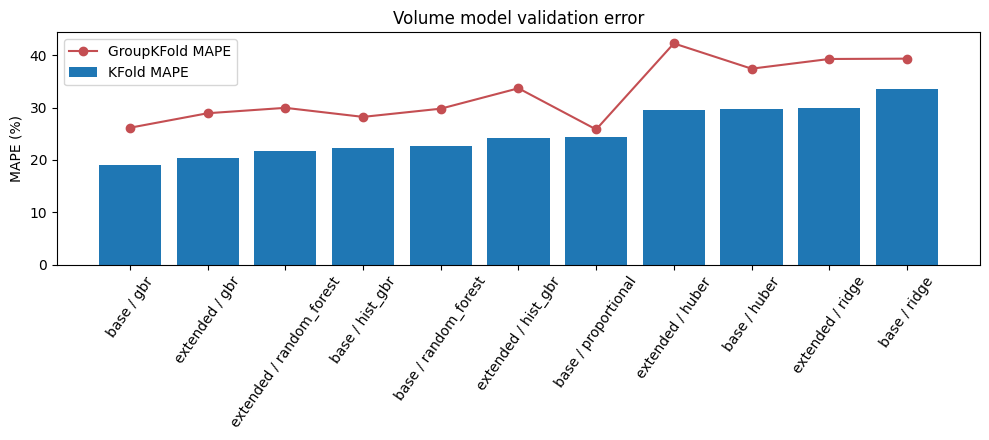

In [4]:
plot_df = leaderboard.copy()
plot_df["label"] = plot_df["feature_set"] + " / " + plot_df["model_kind"]
plot_df = plot_df.sort_values("kfold_MAPE")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(plot_df["label"], plot_df["kfold_MAPE"], label="KFold MAPE")
ax.plot(plot_df["label"], plot_df["group_MAPE"], marker="o", color="#C44E52", label="GroupKFold MAPE")
ax.set_ylabel("MAPE (%)")
ax.set_title("Volume model validation error")
ax.tick_params(axis="x", rotation=55)
ax.legend()
fig.tight_layout()

## 4. Train and save the deployment model

The app default is intentionally the **base geometry** model: `area_cm2`, `height_cm`, `area_x_height`.

Extended shape descriptors are useful in the notebook, but the live app should only depend on features it can measure reliably for every side photo. The artifact still stores a learned proportional shape factor as a fallback.

In [5]:
metrics = {
    "leaderboard": leaderboard.to_dict(orient="records"),
    "deployment_note": (
        "Default app model: GradientBoosting on base geometry; "
        "proportional shape factor retained as fallback."
    ),
}

est = training.fit_final_volume_model(df, metrics=metrics, save_path=config.VOLUME_MODEL_PATH)
print(f"saved: {config.VOLUME_MODEL_PATH}")
print(f"model_kind: {est.model_kind}")
print(f"features: {est.feature_names}")
print(f"fallback shape factor: {est.shape_factor:.6f}")

loaded = VolumeEstimator.load(config.VOLUME_MODEL_PATH)
print(f"loaded model kind: {loaded.model_kind}")
print(f"loaded features: {loaded.feature_names}")

saved: /Users/clemens/Developer/ml4b_foodrecognition/artifacts/volume_model_trained.joblib
model_kind: gbr
features: ('area_cm2', 'height_cm', 'area_x_height')
fallback shape factor: 0.508746
loaded model kind: gbr
loaded features: ('area_cm2', 'height_cm', 'area_x_height')


## 5. Nutrition5k mass-prior audit

Nutrition5k does not contain volume, so it cannot train the volume regressor. It is still useful for auditing the no-side-view fallback: `mass = mass_per_cm2 * area_cm2`.

These priors are not a replacement for side-view volume training. They are the fallback path when height is unavailable.

In [6]:
from pathlib import Path

n5k_path = Path("../artifacts/n5k_features.csv")
if not n5k_path.exists():
    print("Nutrition5k features are not cached. Run data/download_nutrition5k.py and extract_features_n5k first.")
else:
    n5k_report = training.evaluate_n5k_mass_priors(n5k_path)
    display(n5k_report.style.format({"MAPE": "{:.1f}", "MAE_g": "{:.1f}", "mean_mass_g": "{:.1f}"}))

,food_class,n,MAPE,MAE_g,mean_mass_g
22,tuna,1,12.3,12.5,102.0
25,yogurt,5,22.2,35.5,159.0
18,steak,2,25.3,23.7,98.0
19,sweet_potato,19,28.6,35.1,101.3
0,apple,45,32.7,44.5,141.5
3,bread,1,40.8,18.8,46.0
10,mushroom,10,43.4,50.4,104.1
17,sausage,37,46.9,61.9,104.7
4,broccoli,39,48.5,55.6,103.6
12,orange,6,52.6,67.0,127.0


## 6. What to report

Current default model:

* volume artifact: `artifacts/volume_model_trained.joblib`
* deployment features: `area_cm2`, `height_cm`, `area_x_height`
* fallback baseline: `artifacts/volume_regressor.joblib` / learned shape factor `k`
* use in app: only when a side-view height is available
* no-side-view path: per-class `mass_per_cm2` fallback, clearly labelled in the UI

A training run that finishes quickly is expected: this is a small tabular regression problem once the image features are cached. The scientific bottleneck is dataset coverage, not GPU time.